# 3. Data Quality Assessment

Data Quality Assessment is performed after data cleaning to evaluate the reliability, completeness, consistency, validity, uniqueness, and overall usability of the cleaned credit risk dataset.

The objective is to ensure that the dataset is sufficiently reliable for downstream SQL analysis, credit risk analysis, machine learning, and dashboard development.

The assessment focuses on the following dimensions:

- Completeness
- Uniqueness
- Validity
- Consistency
- Accuracy checks
- Timeliness considerations
- Overall Data Quality Score

### 3.1 Load the Cleaned Dataset

The cleaned dataset produced during the Data Cleaning stage is loaded for systematic data quality validation.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("credit_risk_cleaned.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (32416, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 3.2 Completeness

Completeness measures whether required values are present in the dataset.

Missing values can reduce the reliability of statistical analysis and machine learning models. Therefore, the number and percentage of missing values are calculated for every column.

A column with no missing values receives a completeness score of 100%.

In [2]:
completeness = pd.DataFrame({
    "Column": df.columns,
    "Total Records": len(df),
    "Missing Values": df.isnull().sum().values
})
completeness["Completeness (%)"] = ((1 - completeness["Missing Values"] / len(df)) * 100).round(2)
completeness

,Column,Total Records,Missing Values,Completeness (%)
0,person_age,32416,0,100.0
1,person_income,32416,0,100.0
2,person_home_ownership,32416,0,100.0
3,person_emp_length,32416,0,100.0
4,loan_intent,32416,0,100.0
5,loan_grade,32416,0,100.0
6,loan_amnt,32416,0,100.0
7,loan_int_rate,32416,0,100.0
8,loan_status,32416,0,100.0
9,loan_percent_income,32416,0,100.0


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

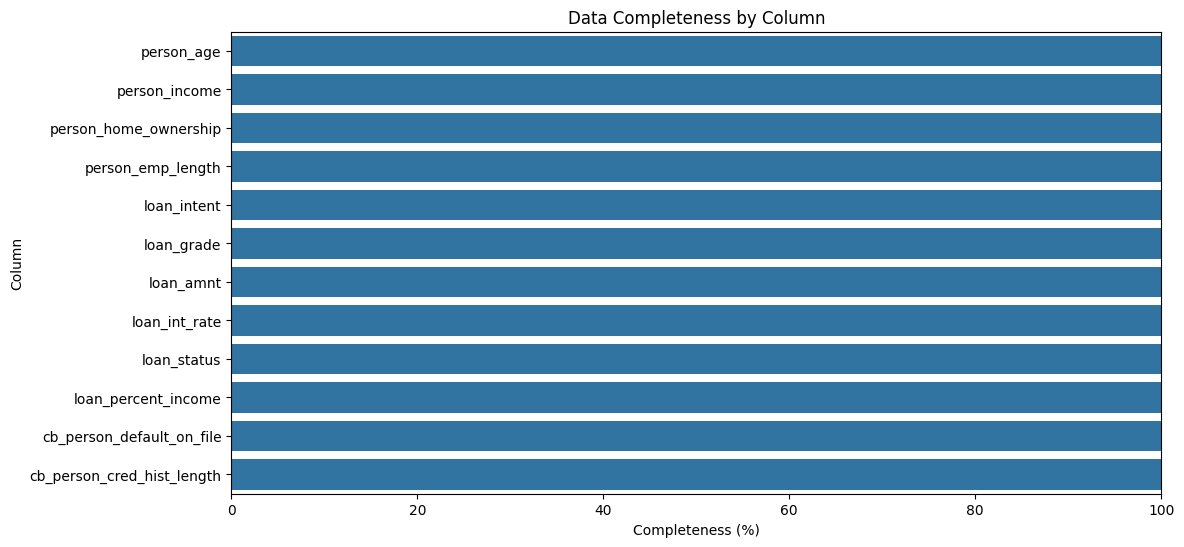

In [6]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=completeness,
    x="Completeness (%)",
    y="Column"
)

plt.title("Data Completeness by Column")
plt.xlabel("Completeness (%)")
plt.ylabel("Column")
plt.xlim(0, 100)

plt.show()

### 3.3 Uniqueness

Uniqueness measures whether records are duplicated.

Duplicate records can result in double-counting and may distort risk calculations and machine learning results.

The cleaned dataset is checked for duplicate rows to determine whether each observation is unique.

In [7]:
duplicate_count = df.duplicated().sum()
uniqueness_percentage = ((len(df) - duplicate_count) / len(df)) * 100
print("Duplicate Records:", duplicate_count)
print("Uniqueness (%):", round(uniqueness_percentage, 2))

Duplicate Records: 0
Uniqueness (%): 100.0


### 3.4 Validity

Validity evaluates whether values conform to expected formats and logical business rules.

For credit-risk data, numerical values should satisfy basic logical constraints such as:

- Age must be positive.
- Income must be greater than zero.
- Loan amount must be greater than zero.
- Employment length cannot be negative.
- Interest rate cannot be negative.
- Loan-to-income percentage cannot be negative.
- Loan status should contain only valid binary values.

In [8]:
validity_checks = {
    "Age > 0": (df["person_age"] > 0).all(),
    "Income > 0": (df["person_income"] > 0).all(),
    "Employment Length >= 0": (df["person_emp_length"] >= 0).all(),
    "Loan Amount > 0": (df["loan_amnt"] > 0).all(),
    "Interest Rate >= 0": (df["loan_int_rate"] >= 0).all(),
    "Loan-to-Income >= 0": (df["loan_percent_income"] >= 0).all(),
    "Loan Status is Binary": set(df["loan_status"].unique()).issubset({0, 1})
}
validity_report = pd.DataFrame(
    list(validity_checks.items()),
    columns=["Validation Rule", "Passed"])
validity_report

,Validation Rule,Passed
0,Age > 0,True
1,Income > 0,True
2,Employment Length >= 0,True
3,Loan Amount > 0,True
4,Interest Rate >= 0,True
5,Loan-to-Income >= 0,True
6,Loan Status is Binary,True


### 3.5 Categorical Consistency

Consistency ensures that categorical variables contain standardized and expected values.

Unexpected spellings, capitalization differences, or invalid categories can cause incorrect grouping and misleading visualizations.

The unique values of important categorical variables are therefore examined.

In [9]:
categorical_columns = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


person_home_ownership
['RENT' 'OWN' 'MORTGAGE' 'OTHER']

loan_intent
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

loan_grade
['D' 'B' 'C' 'A' 'E' 'F' 'G']

cb_person_default_on_file
['Y' 'N']


### 3.6 Expected Category Validation

Expected category sets are defined for important categorical variables.

Each observed value is compared against the expected categories to identify unexpected values.

In [10]:
expected_categories = {
    "person_home_ownership": {"RENT", "OWN", "MORTGAGE", "OTHER"},
    "loan_intent": {
        "PERSONAL",
        "EDUCATION",
        "MEDICAL",
        "VENTURE",
        "HOMEIMPROVEMENT",
        "DEBTCONSOLIDATION"
    },
    "loan_grade": {"A", "B", "C", "D", "E", "F", "G"},
    "cb_person_default_on_file": {"Y", "N"}
}
category_report = []
for column, expected in expected_categories.items():
    observed = set(df[column].dropna().unique())
    unexpected = observed - expected
    category_report.append([
        column,
        len(observed),
        ", ".join(sorted(unexpected)) if unexpected else "None",
        len(unexpected) == 0
    ])
category_report = pd.DataFrame(
    category_report,
    columns=[
        "Column",
        "Unique Categories",
        "Unexpected Values",
        "Passed"
    ]
)
category_report

,Column,Unique Categories,Unexpected Values,Passed
0,person_home_ownership,4,None,True
1,loan_intent,6,None,True
2,loan_grade,7,None,True
3,cb_person_default_on_file,2,None,True


### 3.7 Data Type Quality

Correct data types are essential for reliable calculations, statistical analysis, SQL processing, and machine learning.

The dataset is examined to ensure that numerical variables are stored as numeric values and categorical variables are stored appropriately.

In [11]:
dtype_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})
dtype_report

,Column,Data Type
0,person_age,int64
1,person_income,int64
2,person_home_ownership,object
3,person_emp_length,int64
4,loan_intent,object
5,loan_grade,object
6,loan_amnt,int64
7,loan_int_rate,float64
8,loan_status,int64
9,loan_percent_income,float64


### 3.8 Statistical Quality Checks

Statistical checks are performed to identify unusual values that may indicate data-quality issues.

Minimum, maximum, mean, and median values are examined for important numerical variables.

In [12]:
numeric_columns = df.select_dtypes(include=np.number).columns
statistical_quality = df[numeric_columns].agg(["min", "max", "mean", "median"]).T
statistical_quality

,min,max,mean,median
person_age,20.00,144.00,27.747008,26.00
person_income,4000.00,6000000.00,66091.640826,55000.00
person_emp_length,0.00,123.00,4.768880,4.00
loan_amnt,500.00,35000.00,9593.845632,8000.00
loan_int_rate,5.42,23.22,11.014662,10.99
loan_status,0.00,1.00,0.218688,0.00
loan_percent_income,0.00,0.83,0.170250,0.15
cb_person_cred_hist_length,2.00,30.00,5.811297,4.00


### 3.9 Extreme Value Validation

Extreme observations are reviewed to distinguish between potential data-quality issues and legitimate financial observations.

An extreme value is not automatically considered incorrect. It should be evaluated using logical and domain-specific rules before being removed.

In [13]:
extreme_values = {}
for column in numeric_columns:
    extreme_values[column] = {
        "Minimum": df[column].min(),
        "Maximum": df[column].max()
    }
extreme_values = pd.DataFrame(extreme_values).T
extreme_values

,Minimum,Maximum
person_age,20.00,144.00
person_income,4000.00,6000000.00
person_emp_length,0.00,123.00
loan_amnt,500.00,35000.00
loan_int_rate,5.42,23.22
loan_status,0.00,1.00
loan_percent_income,0.00,0.83
cb_person_cred_hist_length,2.00,30.00


### 3.10 Cross-Field Consistency

Cross-field validation checks whether related variables maintain logical relationships.

For example, `loan_percent_income` represents the relationship between the requested loan amount and applicant income.

A calculated ratio is compared with the recorded value to identify potentially inconsistent records.

In [14]:
df["calculated_loan_percent_income"] = (df["loan_amnt"] / df["person_income"])
df["ratio_difference"] = (df["loan_percent_income"] -df["calculated_loan_percent_income"])
df[["loan_amnt","person_income","loan_percent_income","calculated_loan_percent_income","ratio_difference"]].head()

,loan_amnt,person_income,loan_percent_income,calculated_loan_percent_income,ratio_difference
0,35000,59000,0.59,0.593220,-0.003220
1,1000,9600,0.10,0.104167,-0.004167
2,5500,9600,0.57,0.572917,-0.002917
3,35000,65500,0.53,0.534351,-0.004351
4,35000,54400,0.55,0.643382,-0.093382


### 3.11 Overall Data Quality Score

An overall Data Quality Score is calculated by combining multiple quality dimensions.

The score provides a concise measure of the reliability of the cleaned dataset.

The dimensions used are:

- Completeness: 25%
- Uniqueness: 20%
- Validity: 25%
- Consistency: 20%
- Data Type Quality: 10%

The weighted score ranges from 0 to 100, where a higher score indicates better overall data quality.

In [15]:
completeness_score = (df.isnull().sum().sum() == 0) * 100
uniqueness_score = ((1 - df.duplicated().sum() / len(df)) * 100)
validity_score = (validity_report["Passed"].mean() * 100)
consistency_score = (category_report["Passed"].mean() * 100)
expected_numeric = {
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "loan_status",
    "cb_person_cred_hist_length"
}
numeric_present = set(df.select_dtypes(include=np.number).columns)
dtype_score = (len(expected_numeric.intersection(numeric_present))/ len(expected_numeric)) * 100
quality_score = (completeness_score * 0.25 +uniqueness_score * 0.20 +validity_score * 0.25 +consistency_score * 0.20 +dtype_score * 0.10)
print("Completeness Score:", round(completeness_score, 2))
print("Uniqueness Score:", round(uniqueness_score, 2))
print("Validity Score:", round(validity_score, 2))
print("Consistency Score:", round(consistency_score, 2))
print("Data Type Score:", round(dtype_score, 2))
print("Overall Data Quality Score:", round(quality_score, 2))

Completeness Score: 100
Uniqueness Score: 100.0
Validity Score: 100.0
Consistency Score: 100.0
Data Type Score: 100.0
Overall Data Quality Score: 100.0


### 3.12 Data Quality Score Visualization

The individual quality dimensions are visualized to provide a clear overview of dataset reliability.

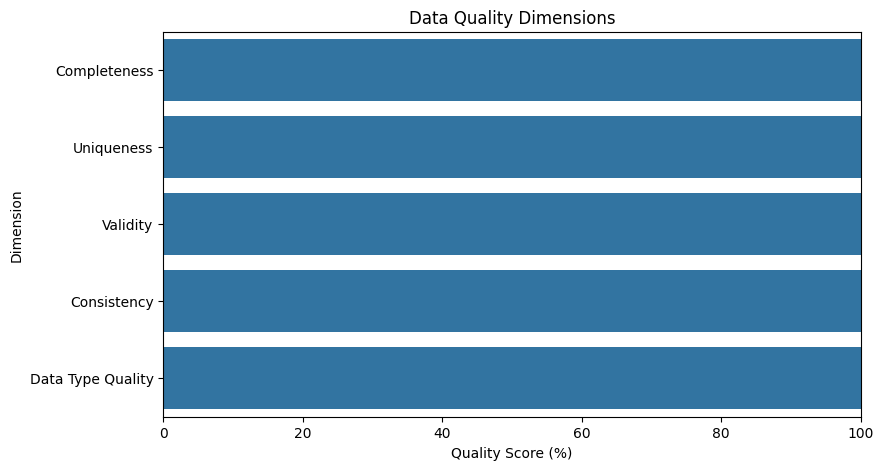

In [16]:
quality_dimensions = pd.DataFrame({"Dimension": ["Completeness","Uniqueness","Validity","Consistency","Data Type Quality"],"Score": [
        completeness_score,
        uniqueness_score,
        validity_score,
        consistency_score,
        dtype_score]})
plt.figure(figsize=(9, 5))
sns.barplot(
    data=quality_dimensions,
    x="Score",
    y="Dimension")
plt.title("Data Quality Dimensions")
plt.xlabel("Quality Score (%)")
plt.ylabel("Dimension")
plt.xlim(0, 100)
plt.show()

### 3.13 Consolidated Data Quality Report

A consolidated report is created to summarize the major quality dimensions and their corresponding scores.

This report can also be exported and used as a supporting artifact for the project.

In [17]:
quality_report = pd.DataFrame({
    "Quality Dimension": [
        "Completeness",
        "Uniqueness",
        "Validity",
        "Consistency",
        "Data Type Quality",
        "Overall Data Quality"
    ],
    "Score (%)": [
        round(completeness_score, 2),
        round(uniqueness_score, 2),
        round(validity_score, 2),
        round(consistency_score, 2),
        round(dtype_score, 2),
        round(quality_score, 2)
    ]
})
quality_report

,Quality Dimension,Score (%)
0,Completeness,100.0
1,Uniqueness,100.0
2,Validity,100.0
3,Consistency,100.0
4,Data Type Quality,100.0
5,Overall Data Quality,100.0


### 3.14 Export Data Quality Report

The consolidated quality report is exported as an Excel file for documentation and future reference.

This report provides a reproducible record of the quality assessment performed on the cleaned dataset.

In [18]:
import os
os.makedirs("reports", exist_ok=True)
quality_report.to_excel("reports/Data_Quality_Report.xlsx",index=False)
print("Data Quality Report saved successfully.")

Data Quality Report saved successfully.


In [19]:
from google.colab import files
files.download("reports/Data_Quality_Report.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

- The cleaned credit risk dataset was evaluated across completeness, uniqueness, validity, consistency, and data-type quality dimensions.
- Missing-value checks confirmed the completeness of the dataset after the data-cleaning process.
- Duplicate-record analysis was performed to ensure that observations were not unnecessarily repeated.
- Numerical variables were validated against logical business rules to identify potentially invalid values.
- Categorical variables were examined for unexpected or inconsistent categories.
- Cross-field validation was performed on related financial variables to identify potential inconsistencies.
- Statistical checks were used to review the range and distribution of important numerical attributes.
- A weighted Data Quality Score was calculated to provide a consolidated measure of dataset reliability.
- The resulting quality assessment provides a documented and reproducible foundation for SQL analysis, credit risk modeling, machine learning, and Power BI reporting.